In [58]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_colwidth', None)  # This shows full column content
# pd.set_option('display.width', None)  # Auto-detect display width
# pd.set_option('display.max_seq_items', None)  # Show all items in lists

In [59]:
df = pd.read_csv('../data/dcInbox/dcinbox_export_114.csv')
unnamed_cols = df.columns.str.contains('^Unnamed')
df = df.loc[:, ~unnamed_cols].copy()
df = df[pd.to_numeric(df['Unix Timestamp'], errors='coerce').notna()].copy()
df['datetime'] = pd.to_datetime(df['Unix Timestamp'], unit='ms')

# Sort chronologically
df = df.sort_values('datetime').reset_index(drop=True)

# Filter data for February and March
# df = df[df['datetime'].between('2016-01-01', '2016-12-31')]
df = df[df['Chamber'] == 'House']
df.info()

/var/folders/02/c1hvrmj11kx0z457p84l6pbc0000gn/T/ipykernel_34296/1599272222.py:1: DtypeWarning: Columns (2,4,10,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,25

<class 'pandas.core.frame.DataFrame'>
Index: 20582 entries, 3 to 24132
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Subject         20581 non-null  object        
 1   Body            20582 non-null  object        
 2   Unix Timestamp  20582 non-null  object        
 3   BioGuide ID     20582 non-null  object        
 4   Congress        20582 non-null  object        
 5   First Name      20582 non-null  object        
 6   Last Name       20582 non-null  object        
 7   Date of Birth   20582 non-null  object        
 8   Gender          20582 non-null  object        
 9   State           20582 non-null  object        
 10  District        20582 non-null  object        
 11  Party           20582 non-null  object        
 12  Chamber         20582 non-null  object        
 13  Nickname        1084 non-null   object        
 14  ID              20582 non-null  object        
 15  datetim

/var/folders/02/c1hvrmj11kx0z457p84l6pbc0000gn/T/ipykernel_34296/1599272222.py:5: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  df['datetime'] = pd.to_datetime(df['Unix Timestamp'], unit='ms')


In [60]:
THEMATIC_LEXICON = {
    # Shared/Bipartisan Categories
    'Healthcare': [
        # From both parties
        'health care',
        'healthcare',
        'obamacare',
        'affordable care act',
        'medicare',
        'medicaid',
        'public health',
        'mental health',
        'health',  # Dem-leaning
        'repeal',  # Rep-leaning (context: "repeal Obamacare")
        'repeal and replace',  # Rep-leaning
        'affordable care', # dem term
    ],
    
    'Education': [
        'education',
        'student',  # Dem focus
        'college',  # Dem focus
        'student loan',  # Dem focus
        'community college',  # Dem focus
        'school choice',  # Rep focus
        'parental rights',  # Rep focus
        'curriculum',
        'crt',  # Rep focus
        'critical race theory',  # Rep focus
        'higher education',  # Dem focus
    ],
    
    'Gun Policy': [
        'gun violence',  # Dem frame
        'gun safety',  # Dem frame
        'gun control',  # Both parties
        'gun reform',  # Dem frame
        'gun',
        'violence',
        'second amendment',  # Rep frame
        '2nd amendment',  # Rep frame
        'gun rights',  # Rep frame
        'right to bear arms',  # Rep frame
        'gun violence'
    ],
    
    # for presentation
    'Immigration': [
        'immigration reform',  # Dem focus
        'immigration policy',
        'border security',  # Both parties
        'border',  # Rep focus
        'southern border',  # Rep focus
        'border crisis',  # Rep focus
        'illegal immigration',  # Rep focus
        'immigration enforcement',  # Rep focus
        'secure the border',  # Rep focus
        'border wall',  # Rep focus
        'sanctuary cities',  # Rep focus
        'illegal',  # Rep focus
        'amnesty',  # Rep focus
    ],
    
    # 'Social Security and Medicare': [
    #     'social security',  # Both parties
    #     'medicare',  # Note: also in Healthcare - intentional
    #     'medicaid',  # Note: also in Healthcare - intentional
    #     'child care',  # Dem focus
    #     'benefit',  # Dem focus
    #     'assistance',  # Dem focus
    #     'entitlements',  # Rep frame
    #     'welfare',  # Rep frame
    # ],
    
    'Congress & Legislation': [
        'legislation',
        'this bill',
        'the bill',
        'house',
        'senate',
        'congress',
        'committee',
        'law',
        'amendment',
        'veto',
        'majority',
        'majority leader',
    ],
    
    # Democratic-Leaning Categories
    # 'Voting Rights': [
    #     'voting rights',
    #     'voting rights act',
    #     'election security',  # Note: also in Rep "Election Integrity"
    #     'vote',
    #     'voting',
    #     'election',
    # ],
    
    # for presentation
    'Civil Rights': [
        'civil rights',
        "women's rights",
        'equality',
        'equal',
        'discrimination',
        'racial justice',
        'racial inequality',
        'systemic racism',
        'social justice',
        'lgbtq',
        'transgender',
        'trans rights',
        'affirmative action',        
    ],
    
    # for presentation
    'Reproductive Rights': [
        'reproductive rights',
        'abortion rights',
        'abortion access',
        'abortion care',
        'planned parenthood',
        'pro-life',
        'prolife',
        'unborn',
        'sanctity of life',
        'abortion',
        'family planning',
        'birth control',
        'roe v wade',
        'anti-abortion',
    ],
    
    # 'Climate and Environmental Policy': [
    #     'climate change',
    #     'renewable energy',
    #     'clean energy',
    #     'green energy',
    #     'climate',
    #     'national park',
    #     'epa',
    #     'environment',
    # ],
    
    # for presentation
    'Criminal Justice Reform': [
        'criminal justice',
        'police reform',
        'criminal justice reform',
        'police',
        'defund the police',
        'back the blue',
        'mass incarceration',
        'prison reform',
        'sentencing reform',
        'police training',
        'community policing',
        'george floyd',
        'breonna taylor',
        'ahmaud arbery',
        'suppport our police',
        'support our law enforcement',
    ],
    
    # 'Housing & Community': [
    #     'housing',
    #     'affordable',
    #     'community',
    #     'neighborhood',
    # ],
    
    # Republican-Leaning Categories
    'Election Integrity': [
        'election integrity',
        'voter fraud',
        'voter id',
        'election reform',
        'voter verification',
        'voting rights act',
        'election security',  # Note: also in Dem "Voting Rights"
        'voting rights',

    ],
    
    # 'Law Enforcement & Crime': [
    #     'law enforcement',
    #     'police',
    #     'law and order',
    #     'crime',
    #     'order',
    #     'public safety',
    # ],
    
    # 'National Security & Defense': [
    #     'national security',
    #     'national defense',
    #     'homeland security',
    #     'defense',
    #     'military',
    #     'veterans',
    #     'armed forces',
    #     'defense spending',
    # ],
    
    # 'Terrorism & Foreign Threats': [
    #     'terrorism',
    #     'terrorist',
    #     'terrorists',
    #     'isis',
    #     'terror',
    #     'guantanamo',
    # ],
    
    # for presentation
    'Iran & Nuclear Policy': [
        'iran',
        'iran deal',
        'nuclear',
        'sanctions',
        'nuclear deal',
    ],
    
    # 'Economy & Taxes': [
    #     'taxes',
    #     'tax',
    #     'tax cuts',
    #     'tax relief',
    #     'tax reform',
    #     'tax code',
    #     'economy',
    #     'jobs',
    #     'economic growth',
    #     'small business',
    #     'business',
    #     'regulations',
    #     'regulatory',
    #     'regulation',
    #     'government spending',
    #     'spending',
    #     'budget',
    #     'deficit',
    #     'middle class',
    #     'minimum wage',  # Dem focus
    #     'wage',  # Dem focus
    # ],
    
    # 'Energy Policy': [
    #     'energy',
    #     'energy independence',
    #     'energy production',
    #     'oil and gas',
    #     'fossil fuels',
    #     'pipeline',
    #     'epa',
    #     'coal',
    #     'natural gas',
    #     'oil',
    #     'gas',
    # ],
    
    # 'Social Issues & Values': [
    #     'religious freedom',
    #     'religious liberty',
    #     'pro-life',
    #     'unborn',
    #     'sanctity of life',
    #     'family values',
    #     'traditional values',
    #     'planned parenthood',
    #     'abortion',  # Note: different frame than Dem "abortion rights"
    #     'god',
    #     'god bless',
    #     'bless',
    #     'christmas',
    # ],
    
    # 'Government Overreach': [
    #     'big government',
    #     'government overreach',
    #     'overreach',
    #     'bureaucracy',
    #     'bureaucrats',
    #     'federal government',
    #     'government',
    #     'mandates',
    #     'federal overreach',
    #     'states rights',
    #     'states',
    #     'freedom',
    #     'liberty',
    #     'conservative',
    #     'constitution',
    #     'constitutional',
    #     'swamp',
    #     'drain the swamp',
    # ],
    
    # 'Supreme Court & Judiciary': [
    #     'supreme court',
    #     'judicial',
    #     'judges',
    #     'department of justice',
    #     'courts',
    # ],
    
    # 'Executive Power': [
    #     'executive',
    #     'executive order',
    #     'power',
    #     'accountability',
    #     'accountable',
    #     'oversight',
    #     'transparency',
    # ],
    
    # 'Patriotic Rhetoric': [
    #     'american',
    #     'american people',
    #     'america first'
    # ]
}

In [61]:
def extract_email_level_matches(df, lexicon):
    """
    Extract phrase and theme matches for each email.
    
    Returns a dataframe with email-level details including matched phrases and themes.
    """
    results = []
    
    for idx, row in df.iterrows():
        full_text = row['Body'].lower()
        
        matched_phrases = []
        matched_themes = set()
        
        # Check each theme and its phrases
        for theme, phrases in lexicon.items():
            for phrase in phrases:
                if phrase.lower() in full_text:
                    matched_phrases.append(phrase)
                    matched_themes.add(theme)
        
        # Only include emails that matched at least one phrase
        if matched_phrases:
            results.append({
                'first_name': row.get('First Name', ''),
                'last_name': row.get('Last Name', ''),
                'party': row.get('Party', ''),
                'ID': row.get('ID'),  # Use index if no 'id' column
                'subject': row.get('Subject', ''),
                'matched_phrases': matched_phrases,
                'themes': list(matched_themes),
                'email': row.get('Body', '')
            })
    
    return pd.DataFrame(results)

def process_lexicon(dataframe, lexicon):
    """Process thematic lexicon and return theme and phrase results"""
    
    # Combine subject and body
    df_copy = dataframe.copy()
    df_copy['full_text'] = (df_copy['Subject'].fillna('').astype(str) + ' ' + 
                            df_copy['Body'].fillna('').astype(str)).str.lower()
    
    phrase_results = []
    theme_results = []
    
    for theme, phrases in lexicon.items():
        # Track which emails mention this theme (any phrase)
        theme_mask = pd.Series([False] * len(df_copy), index=df_copy.index)
        
        for phrase in phrases:
            # Count emails containing this specific phrase
            phrase_mask = df_copy['full_text'].str.contains(phrase, case=False, regex=False)
            count = phrase_mask.sum()
            percentage = (count / len(df_copy)) * 100
            
            phrase_results.append({
                'theme': theme,
                'phrase': phrase,
                'email_count': count,
                'percentage': percentage
            })
            
            # Add to theme mask
            theme_mask = theme_mask | phrase_mask
        
        # Calculate theme-level coverage
        theme_count = theme_mask.sum()
        theme_percentage = (theme_count / len(df_copy)) * 100
        
        theme_results.append({
            'theme': theme,
            'email_count': theme_count,
            'percentage': theme_percentage,
            'num_phrases': len(phrases)
        })
    
    return theme_results, phrase_results

In [62]:
dem_df = df[df['Party'] == 'Democrat'].copy()
print(f"Democrat emails: {len(dem_df)}")

theme_results, phrase_results = process_lexicon(dem_df, THEMATIC_LEXICON)


# Create results dataframes
phrase_df = pd.DataFrame(phrase_results).sort_values('percentage', ascending=False)
theme_df = pd.DataFrame(theme_results).sort_values('percentage', ascending=False)

# Display theme-level summary
print("\n" + "="*70)
print("THEME COVERAGE (emails mentioning ANY phrase in theme)")
print("="*70)

for i, row in enumerate(theme_df.itertuples(), 1):
    print(f"{i:2d}. {row.theme:25s}: {row.email_count:5d} emails ({row.percentage:5.2f}%) [{row.num_phrases} phrases]")

# Display top individual phrases
print("\n" + "="*70)
print("TOP INDIVIDUAL PHRASES BY COVERAGE")
print("="*70)

for i, row in enumerate(phrase_df.head(20).itertuples(), 1):
    print(f"{i:2d}. {row.phrase:30s} ({row.theme:20s}): {row.email_count:5d} ({row.percentage:5.2f}%)")

Democrat emails: 5836

THEME COVERAGE (emails mentioning ANY phrase in theme)
 1. Congress & Legislation   :  5591 emails (95.80%) [12 phrases]
 2. Healthcare               :  2774 emails (47.53%) [12 phrases]
 3. Education                :  2593 emails (44.43%) [11 phrases]
 4. Civil Rights             :  1003 emails (17.19%) [13 phrases]
 5. Gun Policy               :   892 emails (15.28%) [11 phrases]
 6. Immigration              :   626 emails (10.73%) [13 phrases]
 7. Criminal Justice Reform  :   574 emails ( 9.84%) [16 phrases]
 8. Iran & Nuclear Policy    :   402 emails ( 6.89%) [5 phrases]
 9. Election Integrity       :   265 emails ( 4.54%) [8 phrases]
10. Reproductive Rights      :   260 emails ( 4.46%) [14 phrases]

TOP INDIVIDUAL PHRASES BY COVERAGE
 1. congress                       (Congress & Legislation):  5228 (89.58%)
 2. house                          (Congress & Legislation):  3547 (60.78%)
 3. health                         (Healthcare          ):  2440 (41.81%)
 4

In [63]:
rep_df = df[df['Party'] == 'Republican'].copy()
print(f"Republican emails: {len(rep_df)}")

# Combine subject and body
print("\nCombining subject and body text...")
rep_df['full_text'] = (rep_df['Subject'].fillna('').astype(str) + ' ' + 
                        rep_df['Body'].fillna('').astype(str)).str.lower()

theme_results, phrase_results = process_lexicon(rep_df, THEMATIC_LEXICON)


# Create results dataframes
phrase_df = pd.DataFrame(phrase_results).sort_values('percentage', ascending=False)
theme_df = pd.DataFrame(theme_results).sort_values('percentage', ascending=False)

# Display theme-level summary
print("\n" + "="*70)
print("THEME COVERAGE (emails mentioning ANY phrase in theme)")
print("="*70)

for i, row in enumerate(theme_df.itertuples(), 1):
    print(f"{i:2d}. {row.theme:35s}: {row.email_count:5d} emails ({row.percentage:5.2f}%) [{row.num_phrases} phrases]")

# Display top individual phrases
print("\n" + "="*70)
print("TOP INDIVIDUAL PHRASES BY COVERAGE")
print("="*70)

for i, row in enumerate(phrase_df.head(30).itertuples(), 1):
    print(f"{i:2d}. {row.phrase:30s} ({row.theme:30s}): {row.email_count:5d} ({row.percentage:5.2f}%)")

Republican emails: 14746

Combining subject and body text...

THEME COVERAGE (emails mentioning ANY phrase in theme)
 1. Congress & Legislation             : 14538 emails (98.59%) [12 phrases]
 2. Healthcare                         :  6638 emails (45.02%) [12 phrases]
 3. Education                          :  5130 emails (34.79%) [11 phrases]
 4. Iran & Nuclear Policy              :  2501 emails (16.96%) [5 phrases]
 5. Immigration                        :  2284 emails (15.49%) [13 phrases]
 6. Reproductive Rights                :  1592 emails (10.80%) [14 phrases]
 7. Gun Policy                         :  1579 emails (10.71%) [11 phrases]
 8. Criminal Justice Reform            :  1051 emails ( 7.13%) [16 phrases]
 9. Civil Rights                       :   821 emails ( 5.57%) [13 phrases]
10. Election Integrity                 :    48 emails ( 0.33%) [8 phrases]

TOP INDIVIDUAL PHRASES BY COVERAGE
 1. congress                       (Congress & Legislation        ): 13179 (89.37%)
 2. h

In [64]:
emails_email_matches_df = extract_email_level_matches(df, THEMATIC_LEXICON)

# Display summary statistics
print(f"\nTotal emails with theme matches: {len(emails_email_matches_df)}")
print(f"Percentage of emails with matches: {len(emails_email_matches_df)/len(rep_df)*100:.2f}%")

# Show a few examples
print("\nSample of email-level matches:")

emails_email_matches_df.head(5)
emails_email_matches_df.to_csv('../data/dcInbox/email_themes_dcinbox_114_11_22_2025.csv', index=False)


Total emails with theme matches: 20307
Percentage of emails with matches: 137.71%

Sample of email-level matches:


In [65]:
emotion_results_df = pd.read_csv('../data/emotion_scores/emotion_scores_dcinbox_114.csv')
# rename 'id' to 'ID' for consistency
emotion_results_df.rename(columns={'id': 'ID'}, inplace=True)
# join with email themes but only get joy_score, fear_score, anger_score, sadness_score
emails_email_matches_df = emails_email_matches_df.merge(emotion_results_df[['ID', 'joy_score', 'fear_score', 'anger_score', 'sadness_score']], on='ID', how='left')
emails_email_matches_df.head(5)

first_name last_name       party      ID  \
0      Jason     Smith  Republican  101001   
1      Henry   Cuellar    Democrat  101000   
2     Thomas    Massie  Republican  100999   
3    Richard     Hanna  Republican  100997   
4      Louie   Gohmert  Republican  100998   

                                                                                                   subject  \
0                                               Congressman Jason Smith Capitol Report: The Year in Review   
1                                                                                     Congressional Report   
2  PRESS RELEASE: U.S. Representative Thomas Massie Announces He Will Not Vote to Re-elect Speaker Boehner   
3                                                                                        News from Upstate   
4                                               Rep. Louie Gohmert Announces Run for Speaker of the House    

                                                                                      matched_phrases  \
0             [healthcare, health, second amendment, legislation, house, senate, congress, amendment]   
1  [healthcare, health, education, student, higher education, house, congress, law, criminal justice]   
2                                                                        [house, congress, committee]   
3                                                                          [student, house, congress]   
4                                                      [house, senate, congress, committee, majority]   

                                                                     themes  \
0                          [Gun Policy, Healthcare, Congress & Legislation]   
1  [Healthcare, Criminal Justice Reform, Education, Congress & Legislation]   
2                                                  [Congress & Legislation]   
3                                       [Education, Congress & Legislation]   
4                                                  [Congress & Legislation]   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

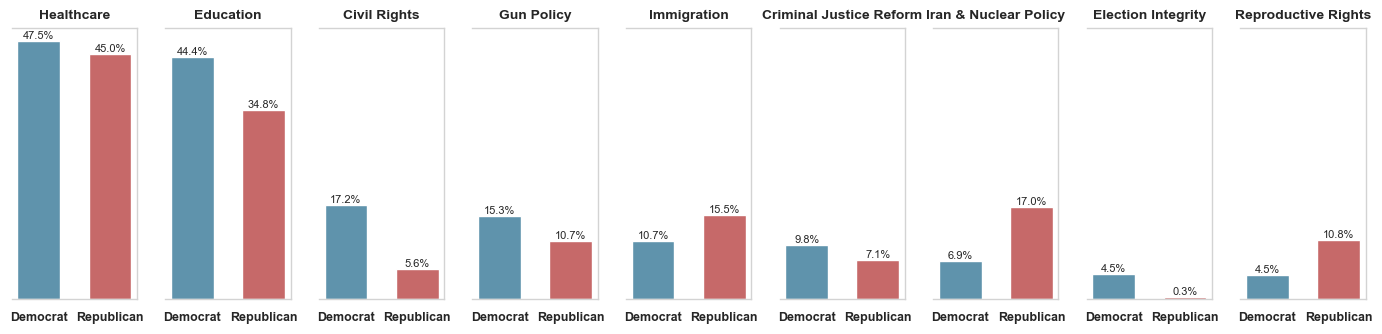

In [67]:
# Font settings
axis_titlesize = 10
axis_labelsize = 9
facet_titlesize = 9
caption_size = 8

# Data from the theme coverage analysis
themes = [
    'Healthcare',
    'Education',
    'Civil Rights',
    'Gun Policy',
    'Immigration',
    'Criminal Justice Reform',
    'Iran & Nuclear Policy',
    'Election Integrity',
    'Reproductive Rights'
]

democrat_percentages = [47.53, 44.43, 17.19, 15.28, 10.73, 9.84, 6.89, 4.54, 4.46]
republican_percentages = [45.02, 34.79, 5.57, 10.71, 15.49, 7.13, 16.96, 0.33, 10.80]

# Create DataFrame
df_themes = pd.DataFrame({
    'theme': themes,
    'Democrat': democrat_percentages,
    'Republican': republican_percentages
})

# Melt to long format
df_melted = df_themes.melt(
    id_vars='theme',
    value_vars=['Democrat', 'Republican'],
    var_name='party',
    value_name='percentage'
)

# Color scheme
dem_med_color = "#5F93AC"
rep_med_color = "#C66969"

sns.set(style="whitegrid")

# Create FacetGrid with one column per theme
g = sns.FacetGrid(
    df_melted,
    col="theme",
    col_order=themes,
    height=4,
    aspect=0.5,  # narrower panels
    despine=False
)

# Create bar plots for each theme
for ax, theme in zip(g.axes.flat, themes):
    theme_data = df_melted[df_melted['theme'] == theme]
    
    # Create bar plot
    for idx, (party, color) in enumerate([("Democrat", dem_med_color), ("Republican", rep_med_color)]):
        party_data = theme_data[theme_data['party'] == party]
        percentage = party_data['percentage'].values[0]
        
        bar = ax.bar(idx, percentage, color=color, width=0.6)
        
        # Add value label on top
        ax.text(idx, percentage, f'{percentage:.1f}%',
                ha='center', va='bottom', fontsize=caption_size)
    
    # Set title (theme name)
    ax.set_title(theme)
    
    # Remove y-axis
    ax.set_ylabel('')
    ax.set_yticks([])
    ax.spines['left'].set_visible(False)
    
    # Set x-axis labels to party names
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Democrat', 'Republican'], fontsize=axis_labelsize, fontweight='bold')
    ax.set_xlabel('')
    
    # Keep light gray spines for remaining edges
    for spine in ['right', 'top', 'bottom']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color("lightgray")
        ax.spines[spine].set_linewidth(1)
    
    # Remove grid
    ax.grid(False)

# No axis labels needed
g.set_axis_labels("", "")

# Force figure size
g.fig.set_size_inches(14, 3.5)

# Style titles
for ax in g.axes.flat:
    ax.tick_params(axis='x', labelsize=axis_labelsize)
    ax.title.set_fontweight("bold")
    ax.title.set_fontsize(axis_titlesize)
    ax.title.set_position((0.5, 1.05))

plt.tight_layout()
plt.savefig('../figures/theme_coverage_comparison.png', dpi=300, bbox_inches='tight')
plt.show()